 # 06 — Gaussian Smoothing of Sampled Spectra



 This notebook evaluates whether Gaussian smoothing of sampled Gaia XP

 spectra improves the performance of selected final functional linear models.



 IMPORTANT:

 Raw models are run using the same modelling and evaluation logic as

 notebook 04:

 - LogisticRegressionCV for functional logistic regression (L2)

 - LinearSVC with inner CV for functional linear SVM

 - train-reference score normalisation

 - Youden threshold selected on the training fold

 - identical repeated stratified CV folds



 Compared models:

 - Raw spectra + functional linear SVM

 - Gaussian-smoothed spectra + functional linear SVM

 - Raw spectra + functional logistic regression (L2)

 - Gaussian-smoothed spectra + functional logistic regression (L2)



 Main comparison metrics:

 - F1

 - PR-AUC



 Main statistical test:

 - Wilcoxon signed-rank test

In [1]:
from __future__ import annotations

import json
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from scipy.stats import wilcoxon

from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



 ## 1. Configuration

In [2]:
BASE_DIR = Path.cwd() / "og_data"
OUT_DIR = Path.cwd() / "results" / "06_smoothing"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_FILE = BASE_DIR / "og_xp.csv"
SAMPLED_FILE = BASE_DIR / "xp_sampled_spectra.csv"
SPLIT_FILE = BASE_DIR / "splits_rskf.json"

SIGMAS = [2.0, 4.0, 6.0]

SMOKE = False
ROW_NORMALIZE = True

INNER_CV = 3
CS_GRID = np.logspace(-2, 2, 6)

LINEAR_MODELS = [
    {
        "method": "Functional logistic regression (L2)",
        "kind": "logreg_l2",
    },
    {
        "method": "Functional linear SVM",
        "kind": "linear_svm",
    },
]

PAIRWISE_COMPARISONS = [
    ("Raw + Functional linear SVM", "Gaussian-smoothed + Functional linear SVM (sigma=2.0)"),
    ("Raw + Functional linear SVM", "Gaussian-smoothed + Functional linear SVM (sigma=4.0)"),
    ("Raw + Functional linear SVM", "Gaussian-smoothed + Functional linear SVM (sigma=6.0)"),
    ("Raw + Functional logistic regression (L2)", "Gaussian-smoothed + Functional logistic regression (L2) (sigma=2.0)"),
    ("Raw + Functional logistic regression (L2)", "Gaussian-smoothed + Functional logistic regression (L2) (sigma=4.0)"),
    ("Raw + Functional logistic regression (L2)", "Gaussian-smoothed + Functional logistic regression (L2) (sigma=6.0)"),
    ("Raw + Functional linear SVM", "Raw + Functional logistic regression (L2)"),
]



 ## 2. Plot style

In [3]:
COLOR_PRIMARY = "#104A7E"
COLOR_SECONDARY = "#78003F"
COLOR_DARK = "#0D1530"
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

SMOOTH_COLORS = {
    0.0: "#4A4A4A",
    2.0: "#6193CD",
    4.0: "#8DB3E2",
    6.0: "#B7D0EE",
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "axes.labelcolor": COLOR_TEXT,
    "xtick.color": COLOR_TEXT,
    "ytick.color": COLOR_TEXT,
    "text.color": COLOR_TEXT,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def apply_clean_axes(ax, add_grid: bool = False, grid_axis: str = "y") -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if add_grid:
        ax.grid(
            True,
            axis=grid_axis,
            linestyle="--",
            linewidth=0.6,
            alpha=0.5,
            color=COLOR_LIGHT,
        )
    else:
        ax.grid(False)


def save_fig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close()



 ## 3. Core helpers from notebook 04

In [4]:
def split_sort_key(k: str) -> tuple[int, int]:
    rep = int(k.split("_")[0].replace("rep", ""))
    fold = int(k.split("_")[1].replace("fold", ""))
    return rep, fold


def row_l2_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms < eps, 1.0, norms)
    return X / norms


def normalize_scores_train_ref(scores_te: np.ndarray, scores_tr: np.ndarray) -> np.ndarray:
    lo = float(np.min(scores_tr))
    hi = float(np.max(scores_tr))

    if hi == lo:
        return np.full_like(scores_te, 0.5, dtype=np.float64)

    out = (scores_te - lo) / (hi - lo)
    return np.clip(out, 0.0, 1.0).astype(np.float64)


def pick_youden_threshold(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    grid_size: int = 200,
) -> float:
    thresholds = np.linspace(0, 1, grid_size)
    best_j = -1.0
    best_thr = 0.5

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(np.int64)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        sens = tp / (tp + fn) if (tp + fn) else 0.0
        spec = tn / (tn + fp) if (tn + fp) else 0.0
        j = sens + spec - 1.0

        if j > best_j:
            best_j = j
            best_thr = float(thr)

    return best_thr


def fold_metrics(
    y_true_te: np.ndarray,
    y_score_te: np.ndarray,
    y_true_tr: np.ndarray,
    y_score_tr: np.ndarray,
) -> dict:
    out = {
        "pr_auc": average_precision_score(y_true_te, y_score_te)
    }

    try:
        out["roc_auc"] = float(roc_auc_score(y_true_te, y_score_te))
    except ValueError:
        out["roc_auc"] = np.nan

    prob_tr = normalize_scores_train_ref(y_score_tr, y_score_tr)
    prob_te = normalize_scores_train_ref(y_score_te, y_score_tr)

    thr = pick_youden_threshold(y_true_tr, prob_tr)
    y_pred = (prob_te >= thr).astype(np.int64)

    out["youden_threshold"] = thr
    out["sensitivity"] = recall_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["recall"] = out["sensitivity"]
    out["precision"] = precision_score(y_true_te, y_pred, pos_label=1, zero_division=0)
    out["specificity"] = recall_score(y_true_te, y_pred, pos_label=0, zero_division=0)
    out["accuracy"] = accuracy_score(y_true_te, y_pred)
    out["f1"] = f1_score(y_true_te, y_pred, pos_label=1, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    out["youden_j"] = sens + spec - 1.0

    return out


def mean_inner_cv_roc_auc_at_best_c(clf: LogisticRegressionCV) -> float:
    sc = clf.scores_

    if sc is None:
        return np.nan

    if isinstance(sc, dict):
        arr = np.asarray(next(iter(sc.values())))
    elif hasattr(sc, "ndim") and sc.ndim == 3:
        arr = sc[0]
    else:
        arr = np.asarray(sc)

    c_grid = np.asarray(clf.Cs_)
    best_c = float(clf.C_[0])
    j = int(np.argmin(np.abs(c_grid - best_c)))

    return float(np.mean(arr[:, j]))


def run_linear_model_one_split(
    X: np.ndarray,
    y: np.ndarray,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    kind: str,
) -> tuple[dict, np.ndarray]:
    X_tr = X[train_idx]
    X_te = X[test_idx]
    y_tr = y[train_idx]
    y_te = y[test_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    if kind == "logreg_l2":
        model = LogisticRegressionCV(
            Cs=CS_GRID,
            cv=StratifiedKFold(
                n_splits=INNER_CV,
                shuffle=True,
                random_state=RANDOM_STATE,
            ),
            penalty="l2",
            solver="lbfgs",
            class_weight="balanced",
            scoring="roc_auc",
            max_iter=2000,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

        model.fit(X_tr_s, y_tr)

        score_tr = model.predict_proba(X_tr_s)[:, 1]
        score_te = model.predict_proba(X_te_s)[:, 1]
        coef = model.coef_[0].copy()

        extra = {
            "best_C": float(model.C_[0]),
            "best_cv_roc_auc": mean_inner_cv_roc_auc_at_best_c(model),
            "n_nonzero_coefs": int(X.shape[1]),
        }

    elif kind == "linear_svm":
        inner_cv = StratifiedKFold(
            n_splits=INNER_CV,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

        c_scores = []

        for C in CS_GRID:
            fold_scores = []

            for inner_tr, inner_va in inner_cv.split(X_tr_s, y_tr):
                clf = LinearSVC(
                    C=C,
                    class_weight="balanced",
                    max_iter=10000,
                    random_state=RANDOM_STATE,
                )

                clf.fit(X_tr_s[inner_tr], y_tr[inner_tr])
                va_score = clf.decision_function(X_tr_s[inner_va])

                try:
                    auc = roc_auc_score(y_tr[inner_va], va_score)
                except ValueError:
                    auc = np.nan

                fold_scores.append(auc)

            c_scores.append(np.nanmean(fold_scores))

        best_i = int(np.nanargmax(c_scores))
        best_c = float(CS_GRID[best_i])

        model = LinearSVC(
            C=best_c,
            class_weight="balanced",
            max_iter=10000,
            random_state=RANDOM_STATE,
        )

        model.fit(X_tr_s, y_tr)

        score_tr = model.decision_function(X_tr_s)
        score_te = model.decision_function(X_te_s)
        coef = model.coef_[0].copy()

        extra = {
            "best_C": best_c,
            "best_cv_roc_auc": float(c_scores[best_i]),
            "n_nonzero_coefs": int(np.sum(np.abs(coef) > 1e-12)),
        }

    else:
        raise ValueError(f"Unsupported kind: {kind}")

    metrics = fold_metrics(y_te, score_te, y_tr, score_tr)
    metrics.update(extra)

    return metrics, coef



 ## 4. Smoothing and summary helpers

In [5]:
def build_gaussian_smoother(wavelengths: np.ndarray, sigma: float) -> np.ndarray:
    wl = wavelengths.reshape(-1, 1)
    d2 = (wl - wl.T) ** 2

    W = np.exp(-0.5 * d2 / (sigma ** 2))
    W /= W.sum(axis=1, keepdims=True)

    return W


def apply_smoother(X: np.ndarray, smoother: np.ndarray) -> np.ndarray:
    return X @ smoother.T


def summarise_run(df_run: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    metric_cols = [
        "pr_auc", "roc_auc", "sensitivity", "precision",
        "specificity", "accuracy", "f1", "youden_j",
        "youden_threshold", "best_C", "best_cv_roc_auc",
        "n_nonzero_coefs",
    ]

    agg_dict = {}

    for m in metric_cols:
        if m in df_run.columns:
            agg_dict[f"{m}_mean"] = pd.NamedAgg(column=m, aggfunc="mean")
            agg_dict[f"{m}_std"] = pd.NamedAgg(column=m, aggfunc="std")

    return df_run.groupby(group_cols).agg(**agg_dict).reset_index()


def run_wilcoxon_tests(
    fold_df: pd.DataFrame,
    pairs: Sequence[tuple[str, str]],
    metrics: Sequence[str] = ("f1", "pr_auc"),
) -> pd.DataFrame:
    records = []

    for model_a, model_b in pairs:
        sub_a = fold_df[fold_df["model"] == model_a].copy()
        sub_b = fold_df[fold_df["model"] == model_b].copy()

        common_splits = sorted(set(sub_a["split"]).intersection(set(sub_b["split"])))

        sub_a = sub_a[sub_a["split"].isin(common_splits)].sort_values("split")
        sub_b = sub_b[sub_b["split"].isin(common_splits)].sort_values("split")

        if len(sub_a) == 0 or len(sub_b) == 0:
            continue

        for metric in metrics:
            a_vals = sub_a[metric].to_numpy()
            b_vals = sub_b[metric].to_numpy()
            diff = a_vals - b_vals

            nonzero = np.sum(np.abs(diff) > 1e-12)

            if nonzero == 0:
                stat = np.nan
                p = 1.0
            else:
                try:
                    stat, p = wilcoxon(
                        a_vals,
                        b_vals,
                        zero_method="wilcox",
                        alternative="two-sided",
                    )
                except ValueError:
                    stat, p = np.nan, np.nan

            records.append({
                "model_a": model_a,
                "model_b": model_b,
                "metric": metric,
                "n_folds": len(a_vals),
                "mean_a": float(np.nanmean(a_vals)),
                "mean_b": float(np.nanmean(b_vals)),
                "mean_diff_a_minus_b": float(np.nanmean(diff)),
                "wilcoxon_stat": stat,
                "p_value": p,
                "significant_0_05": bool(p < 0.05) if pd.notna(p) else False,
            })

    return pd.DataFrame(records)


def summarise_weight_functions(weight_df: pd.DataFrame) -> pd.DataFrame:
    return (
        weight_df
        .groupby(["model", "wavelength"])["weight"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "weight_mean", "std": "weight_std"})
    )


def ms(mean, std):
    if pd.isna(mean):
        return np.nan
    return f"{mean:.4f} ± {0.0 if pd.isna(std) else std:.4f}"



 ## 5. Plot helpers

In [6]:
def plot_class_mean_spectra(
    X_data: np.ndarray,
    y: np.ndarray,
    wavelengths: np.ndarray,
    out_path: Path,
) -> None:
    mean_0 = X_data[y == 0].mean(axis=0)
    mean_1 = X_data[y == 1].mean(axis=0)

    fig, ax = plt.subplots(figsize=(10, 4.8))

    ax.plot(
        wavelengths,
        mean_0,
        linewidth=2.4,
        color=COLOR_SECONDARY,
        label="Nedvinarė",
    )

    ax.plot(
        wavelengths,
        mean_1,
        linewidth=2.4,
        color=COLOR_PRIMARY,
        label="Dvinarė",
    )

    ax.set_xlabel("Bangos ilgis, nm")
    ax.set_ylabel("Vidutinis L2 normalizuotas srautas")
    ax.legend(frameon=False, loc="best")

    apply_clean_axes(ax, add_grid=False)
    save_fig(out_path)


def plot_class_mean_difference(
    X_data: np.ndarray,
    y: np.ndarray,
    wavelengths: np.ndarray,
    out_path: Path,
) -> None:
    mean_0 = X_data[y == 0].mean(axis=0)
    mean_1 = X_data[y == 1].mean(axis=0)
    diff = mean_1 - mean_0

    fig, ax = plt.subplots(figsize=(10, 4.8))

    ax.plot(
        wavelengths,
        diff,
        linewidth=2.2,
        color=COLOR_PRIMARY,
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=0.9,
        color=COLOR_DARK,
    )

    ax.set_xlabel("Bangos ilgis, nm")
    ax.set_ylabel("Vidurkių skirtumas")

    apply_clean_axes(ax, add_grid=False)
    save_fig(out_path)


def translate_model_label(model_name: str) -> str:
    if model_name == "Raw + Functional linear SVM":
        return "Neapdoroti + tiesinis SVM"

    if model_name.startswith("Gaussian-smoothed + Functional linear SVM"):
        sigma = model_name.split("sigma=")[1].replace(")", "")
        return f"Glodinti + tiesinis SVM, σ={sigma}"

    if model_name == "Raw + Functional logistic regression (L2)":
        return "Neapdoroti + logistinė regresija"

    if model_name.startswith("Gaussian-smoothed + Functional logistic regression (L2)"):
        sigma = model_name.split("sigma=")[1].replace(")", "")
        return f"Glodinti + logistinė regresija, σ={sigma}"

    return model_name


def plot_raw_vs_smoothed_weights(
    weight_summary_df: pd.DataFrame,
    raw_model: str,
    smooth_model: str,
    out_path: Path,
) -> None:
    keep_models = [raw_model, smooth_model]
    sub = weight_summary_df[weight_summary_df["model"].isin(keep_models)].copy()

    if sub.empty:
        return

    fig, ax = plt.subplots(figsize=(11, 5.5))

    for model_name in keep_models:
        s = sub[sub["model"] == model_name].sort_values("wavelength")

        if s.empty:
            continue

        sigma_value = 0.0

        if "sigma=" in model_name:
            sigma_value = float(model_name.split("sigma=")[1].replace(")", ""))

        ax.plot(
            s["wavelength"],
            s["weight_mean"],
            linewidth=2.2,
            label=translate_model_label(model_name),
            color=SMOOTH_COLORS.get(sigma_value, COLOR_PRIMARY),
        )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=0.9,
        color=COLOR_DARK,
    )

    ax.set_xlabel("Bangos ilgis, nm")
    ax.set_ylabel("Svoris")
    ax.legend(frameon=False, loc="best")

    apply_clean_axes(ax, add_grid=False)
    save_fig(out_path)


def plot_metric_boxplot(
    fold_metrics_df: pd.DataFrame,
    plot_order: list[str],
    metric: str,
    ylabel: str,
    out_path: Optional[Path] = None,
    show: bool = False,
) -> None:
    fig, ax = plt.subplots(figsize=(11, 6))

    data = [
        fold_metrics_df.loc[fold_metrics_df["model"] == model, metric].values
        for model in plot_order
    ]

    ax.boxplot(data, labels=plot_order, vert=True)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(plot_order, rotation=20, ha="right")

    apply_clean_axes(ax, add_grid=True, grid_axis="y")

    if out_path is not None:
        save_fig(out_path)

    if show:
        plt.show()



 ## 6. Load data

In [7]:
if not LABEL_FILE.exists():
    raise FileNotFoundError(f"Missing file: {LABEL_FILE}")

if not SAMPLED_FILE.exists():
    raise FileNotFoundError(f"Missing file: {SAMPLED_FILE}")

if not SPLIT_FILE.exists():
    raise FileNotFoundError(f"Missing file: {SPLIT_FILE}")

df_labels = pd.read_csv(LABEL_FILE)
df_spec = pd.read_csv(SAMPLED_FILE)

if "source_id" not in df_labels.columns or "y" not in df_labels.columns:
    raise ValueError("og_xp.csv must contain `source_id` and `y`.")

if "source_id" not in df_spec.columns:
    raise ValueError("xp_sampled_spectra.csv must contain `source_id`.")

wl_cols = [c for c in df_spec.columns if c.startswith("wl_")]

if len(wl_cols) == 0:
    raise ValueError("No wavelength columns found. Expected columns like `wl_336`.")

wl_cols = sorted(wl_cols, key=lambda x: float(x.replace("wl_", "")))
wavelengths = np.array([float(c.replace("wl_", "")) for c in wl_cols], dtype=np.float64)

df_m = df_labels[["source_id", "y"]].merge(
    df_spec[["source_id"] + wl_cols],
    on="source_id",
    how="inner",
    validate="one_to_one",
)

X_raw_input = df_m[wl_cols].to_numpy(dtype=np.float64)
y = df_m["y"].to_numpy(dtype=np.int64)
source_ids = df_m["source_id"].to_numpy()

if ROW_NORMALIZE:
    X_raw = row_l2_normalize(X_raw_input)
else:
    X_raw = X_raw_input.copy()

with open(SPLIT_FILE, "r", encoding="utf-8") as f:
    splits = json.load(f)

split_names = sorted(splits.keys(), key=split_sort_key)

if SMOKE:
    split_names = [k for k in split_names if k.startswith("rep0_")]

print("Merged rows:", len(df_m))
print("X shape:", X_raw.shape)
print("Class counts:")
print(pd.Series(y).value_counts().sort_index())
print("Binary fraction:", round((y == 1).mean(), 4))
print("Number of splits:", len(split_names))
print("Wavelength range:", wavelengths.min(), "to", wavelengths.max())



Merged rows: 2815
X shape: (2815, 343)
Class counts:
0    2257
1     558
Name: count, dtype: int64
Binary fraction: 0.1982
Number of splits: 50
Wavelength range: 336.0 to 1020.0


 ## 7. Build smoothed spectra

In [8]:
X_smooth_dict = {}

for sigma in SIGMAS:
    smoother = build_gaussian_smoother(wavelengths=wavelengths, sigma=sigma)
    X_smooth_dict[sigma] = apply_smoother(X_raw, smoother)

print("Built smoothed spectra for sigmas:", SIGMAS)



Built smoothed spectra for sigmas: [2.0, 4.0, 6.0]


 ## 8. Save raw and smoothed class-level plots

In [9]:
plot_class_mean_spectra(
    X_data=X_raw,
    y=y,
    wavelengths=wavelengths,
    out_path=OUT_DIR / "fig_raw_class_mean_spectra.svg",
)

plot_class_mean_difference(
    X_data=X_raw,
    y=y,
    wavelengths=wavelengths,
    out_path=OUT_DIR / "fig_raw_class_mean_difference.svg",
)

for sigma in SIGMAS:
    plot_class_mean_spectra(
        X_data=X_smooth_dict[sigma],
        y=y,
        wavelengths=wavelengths,
        out_path=OUT_DIR / f"fig_smoothed_class_mean_spectra_sigma_{sigma}.svg",
    )

    plot_class_mean_difference(
        X_data=X_smooth_dict[sigma],
        y=y,
        wavelengths=wavelengths,
        out_path=OUT_DIR / f"fig_smoothed_class_mean_difference_sigma_{sigma}.svg",
    )

print("Saved class-level figures to:", OUT_DIR)



Saved class-level figures to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\06_smoothing


 ## 9. Run repeated-fold evaluation

In [10]:
all_results = []
all_weights = []

for fold_i, sname in enumerate(split_names, start=1):
    print(f"[{fold_i}/{len(split_names)}] Current fold: {sname}")

    tr_idx = np.array(splits[sname]["train"], dtype=int)
    te_idx = np.array(splits[sname]["test"], dtype=int)

    for cfg in LINEAR_MODELS:
        method = cfg["method"]
        kind = cfg["kind"]

        # Raw version
        raw_model_name = f"Raw + {method}"

        print(f"  -> {raw_model_name}")

        met, coef = run_linear_model_one_split(
            X=X_raw,
            y=y,
            train_idx=tr_idx,
            test_idx=te_idx,
            kind=kind,
        )

        row = {
            "split": sname,
            "model": raw_model_name,
            "method": method,
            "kind": kind,
            "representation": "Raw spectra",
            "sigma": 0.0,
        }
        row.update(met)
        all_results.append(row)

        for wl, w in zip(wavelengths, coef):
            all_weights.append({
                "split": sname,
                "model": raw_model_name,
                "method": method,
                "kind": kind,
                "representation": "Raw spectra",
                "sigma": 0.0,
                "wavelength": float(wl),
                "weight": float(w),
            })

        # Smoothed versions
        for sigma in SIGMAS:
            smooth_model_name = f"Gaussian-smoothed + {method} (sigma={sigma})"

            print(f"  -> {smooth_model_name}")

            met, coef = run_linear_model_one_split(
                X=X_smooth_dict[sigma],
                y=y,
                train_idx=tr_idx,
                test_idx=te_idx,
                kind=kind,
            )

            row = {
                "split": sname,
                "model": smooth_model_name,
                "method": method,
                "kind": kind,
                "representation": "Gaussian-smoothed spectra",
                "sigma": sigma,
            }
            row.update(met)
            all_results.append(row)

            for wl, w in zip(wavelengths, coef):
                all_weights.append({
                    "split": sname,
                    "model": smooth_model_name,
                    "method": method,
                    "kind": kind,
                    "representation": "Gaussian-smoothed spectra",
                    "sigma": sigma,
                    "wavelength": float(wl),
                    "weight": float(w),
                })

fold_metrics_df = pd.DataFrame(all_results)
weight_functions_df = pd.DataFrame(all_weights)

print("\nFold metrics shape:", fold_metrics_df.shape)
display(fold_metrics_df.head())

print("\nWeight functions shape:", weight_functions_df.shape)
display(weight_functions_df.head())



[1/50] Current fold: rep0_fold0
  -> Raw + Functional logistic regression (L2)
  -> Gaussian-smoothed + Functional logistic regression (L2) (sigma=2.0)
  -> Gaussian-smoothed + Functional logistic regression (L2) (sigma=4.0)
  -> Gaussian-smoothed + Functional logistic regression (L2) (sigma=6.0)
  -> Raw + Functional linear SVM
  -> Gaussian-smoothed + Functional linear SVM (sigma=2.0)
  -> Gaussian-smoothed + Functional linear SVM (sigma=4.0)
  -> Gaussian-smoothed + Functional linear SVM (sigma=6.0)
[2/50] Current fold: rep0_fold1
  -> Raw + Functional logistic regression (L2)
  -> Gaussian-smoothed + Functional logistic regression (L2) (sigma=2.0)
  -> Gaussian-smoothed + Functional logistic regression (L2) (sigma=4.0)
  -> Gaussian-smoothed + Functional logistic regression (L2) (sigma=6.0)
  -> Raw + Functional linear SVM
  -> Gaussian-smoothed + Functional linear SVM (sigma=2.0)
  -> Gaussian-smoothed + Functional linear SVM (sigma=4.0)
  -> Gaussian-smoothed + Functional linear 

,split,model,method,kind,representation,sigma,pr_auc,roc_auc,youden_threshold,sensitivity,recall,precision,specificity,accuracy,f1,youden_j,best_C,best_cv_roc_auc,n_nonzero_coefs
0,rep0_fold0,Raw + Functional logistic regression (L2),Functional logistic regression (L2),logreg_l2,Raw spectra,0.0,0.852218,0.947002,0.482412,0.864865,0.864865,0.727273,0.920354,0.909414,0.790123,0.785219,100.000000,0.915452,343
1,rep0_fold0,Gaussian-smoothed + Functional logistic regres...,Functional logistic regression (L2),logreg_l2,Gaussian-smoothed spectra,2.0,0.863505,0.949872,0.472362,0.873874,0.873874,0.734848,0.922566,0.912966,0.798354,0.796440,100.000000,0.914975,343
2,rep0_fold0,Gaussian-smoothed + Functional logistic regres...,Functional logistic regression (L2),logreg_l2,Gaussian-smoothed spectra,4.0,0.880757,0.957566,0.432161,0.900901,0.900901,0.709220,0.909292,0.907638,0.793651,0.810193,15.848932,0.913000,343
3,rep0_fold0,Gaussian-smoothed + Functional logistic regres...,Functional logistic regression (L2),logreg_l2,Gaussian-smoothed spectra,6.0,0.874574,0.954357,0.447236,0.900901,0.900901,0.751880,0.926991,0.921847,0.819672,0.827892,15.848932,0.911522,343
4,rep0_fold0,Raw + Functional linear SVM,Functional linear SVM,linear_svm,Raw spectra,0.0,0.855020,0.947660,0.733668,0.855856,0.855856,0.748031,0.929204,0.914742,0.798319,0.785059,15.848932,0.911512,343



Weight functions shape: (137200, 8)


,split,model,method,kind,representation,sigma,wavelength,weight
0,rep0_fold0,Raw + Functional logistic regression (L2),Functional logistic regression (L2),logreg_l2,Raw spectra,0.0,336.0,-2.142370
1,rep0_fold0,Raw + Functional logistic regression (L2),Functional logistic regression (L2),logreg_l2,Raw spectra,0.0,338.0,3.431993
2,rep0_fold0,Raw + Functional logistic regression (L2),Functional logistic regression (L2),logreg_l2,Raw spectra,0.0,340.0,-4.234910
3,rep0_fold0,Raw + Functional logistic regression (L2),Functional logistic regression (L2),logreg_l2,Raw spectra,0.0,342.0,-11.018308
4,rep0_fold0,Raw + Functional logistic regression (L2),Functional logistic regression (L2),logreg_l2,Raw spectra,0.0,344.0,-7.607043


 ## 10. Summary tables

In [11]:
summary_df = summarise_run(
    fold_metrics_df,
    ["model", "method", "kind", "representation", "sigma"],
)

summary_df = summary_df.sort_values(
    ["f1_mean", "pr_auc_mean", "roc_auc_mean"],
    ascending=False,
).reset_index(drop=True)

pretty_summary = pd.DataFrame({
    "Model": summary_df["model"],
    "F1": [ms(m, s) for m, s in zip(summary_df["f1_mean"], summary_df["f1_std"])],
    "PR-AUC": [ms(m, s) for m, s in zip(summary_df["pr_auc_mean"], summary_df["pr_auc_std"])],
    "ROC-AUC": [ms(m, s) for m, s in zip(summary_df["roc_auc_mean"], summary_df["roc_auc_std"])],
    "Sensitivity": [ms(m, s) for m, s in zip(summary_df["sensitivity_mean"], summary_df["sensitivity_std"])],
    "Precision": [ms(m, s) for m, s in zip(summary_df["precision_mean"], summary_df["precision_std"])],
    "Best C": [ms(m, s) for m, s in zip(summary_df["best_C_mean"], summary_df["best_C_std"])],
})

print("=== SUMMARY ===")
display(pretty_summary)



=== SUMMARY ===


,Model,F1,PR-AUC,ROC-AUC,Sensitivity,Precision,Best C
0,Gaussian-smoothed + Functional logistic regres...,0.7757 ± 0.0286,0.8090 ± 0.0453,0.9225 ± 0.0150,0.8212 ± 0.0327,0.7367 ± 0.0423,41.9771 ± 40.3308
1,Gaussian-smoothed + Functional logistic regres...,0.7739 ± 0.0303,0.8080 ± 0.0451,0.9219 ± 0.0144,0.8204 ± 0.0338,0.7343 ± 0.0459,46.7594 ± 42.2542
2,Raw + Functional logistic regression (L2),0.7727 ± 0.0264,0.8061 ± 0.0439,0.9223 ± 0.0137,0.8183 ± 0.0322,0.7342 ± 0.0469,50.1254 ± 43.0181
3,Gaussian-smoothed + Functional logistic regres...,0.7717 ± 0.0287,0.8076 ± 0.0429,0.9219 ± 0.0137,0.8185 ± 0.0325,0.7319 ± 0.0454,45.0764 ± 41.7633
4,Gaussian-smoothed + Functional linear SVM (sig...,0.7119 ± 0.0743,0.7996 ± 0.0430,0.9158 ± 0.0143,0.7801 ± 0.1019,0.6912 ± 0.1530,34.7431 ± 41.5287
5,Gaussian-smoothed + Functional linear SVM (sig...,0.7055 ± 0.0689,0.7947 ± 0.0405,0.9155 ± 0.0134,0.7596 ± 0.1111,0.7024 ± 0.1608,30.5029 ± 35.4450
6,Gaussian-smoothed + Functional linear SVM (sig...,0.7052 ± 0.0825,0.7980 ± 0.0403,0.9154 ± 0.0138,0.7967 ± 0.0875,0.6675 ± 0.1627,33.3355 ± 38.2066
7,Raw + Functional linear SVM,0.6934 ± 0.0744,0.7930 ± 0.0412,0.9157 ± 0.0132,0.7790 ± 0.1170,0.6674 ± 0.1579,31.9192 ± 36.8794


 ## 11. Wilcoxon signed-rank tests

In [12]:
wilcoxon_df = run_wilcoxon_tests(
    fold_df=fold_metrics_df,
    pairs=PAIRWISE_COMPARISONS,
    metrics=("f1", "pr_auc"),
)

print("=== WILCOXON TESTS ===")
display(wilcoxon_df)



=== WILCOXON TESTS ===


,model_a,model_b,metric,n_folds,mean_a,mean_b,mean_diff_a_minus_b,wilcoxon_stat,p_value,significant_0_05
0,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,f1,50,0.693444,0.705542,-0.012098,565.0,4.903262e-01,False
1,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,pr_auc,50,0.792991,0.794722,-0.001731,578.0,5.720861e-01,False
2,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,f1,50,0.693444,0.705158,-0.011714,558.0,4.490068e-01,False
3,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,pr_auc,50,0.792991,0.797964,-0.004972,489.0,1.543025e-01,False
4,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,f1,50,0.693444,0.711891,-0.018447,521.0,2.653377e-01,False
5,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,pr_auc,50,0.792991,0.799576,-0.006584,443.0,6.070140e-02,False
6,Raw + Functional logistic regression (L2),Gaussian-smoothed + Functional logistic regres...,f1,50,0.772698,0.771674,0.001024,569.0,8.454913e-01,False
7,Raw + Functional logistic regression (L2),Gaussian-smoothed + Functional logistic regres...,pr_auc,50,0.806062,0.807620,-0.001558,512.0,2.297480e-01,False
8,Raw + Functional logistic regression (L2),Gaussian-smoothed + Functional logistic regres...,f1,50,0.772698,0.773893,-0.001195,632.0,9.618479e-01,False
9,Raw + Functional logistic regression (L2),Gaussian-smoothed + Functional logistic regres...,pr_auc,50,0.806062,0.807988,-0.001925,490.0,1.571404e-01,False


 ## 12. Weight-function summaries

In [13]:
weight_summary_df = summarise_weight_functions(weight_functions_df)

ranking = (
    fold_metrics_df
    .groupby("model")[["f1", "pr_auc", "accuracy", "roc_auc", "sensitivity", "precision"]]
    .mean()
    .sort_values(["f1", "pr_auc"], ascending=False)
    .reset_index()
)

print("=== MEAN RANKING ===")
display(ranking)



=== MEAN RANKING ===


,model,f1,pr_auc,accuracy,roc_auc,sensitivity,precision
0,Gaussian-smoothed + Functional logistic regres...,0.775742,0.808958,0.905648,0.922505,0.821155,0.736696
1,Gaussian-smoothed + Functional logistic regres...,0.773893,0.807988,0.904654,0.921906,0.820431,0.734271
2,Raw + Functional logistic regression (L2),0.772698,0.806062,0.904263,0.922291,0.818285,0.734230
3,Gaussian-smoothed + Functional logistic regres...,0.771674,0.807620,0.903694,0.921912,0.818477,0.731881
4,Gaussian-smoothed + Functional linear SVM (sig...,0.711891,0.799576,0.867531,0.915840,0.780055,0.691180
5,Gaussian-smoothed + Functional linear SVM (sig...,0.705542,0.794722,0.867389,0.915545,0.759596,0.702395
6,Gaussian-smoothed + Functional linear SVM (sig...,0.705158,0.797964,0.856945,0.915448,0.796691,0.667490
7,Raw + Functional linear SVM,0.693444,0.792991,0.855595,0.915735,0.778988,0.667430


 ## 13. Choose best smoothing level for each estimator

In [14]:
svm_candidates = summary_df[
    summary_df["method"] == "Functional linear SVM"
].copy()

logreg_candidates = summary_df[
    summary_df["method"] == "Functional logistic regression (L2)"
].copy()

best_svm_model = (
    svm_candidates
    .sort_values(["f1_mean", "pr_auc_mean", "roc_auc_mean"], ascending=False)
    .iloc[0]["model"]
)

best_logreg_model = (
    logreg_candidates
    .sort_values(["f1_mean", "pr_auc_mean", "roc_auc_mean"], ascending=False)
    .iloc[0]["model"]
)

best_sigma_svm = 0.0 if best_svm_model.startswith("Raw") else float(
    best_svm_model.split("sigma=")[1].replace(")", "")
)

best_sigma_logreg = 0.0 if best_logreg_model.startswith("Raw") else float(
    best_logreg_model.split("sigma=")[1].replace(")", "")
)

print("Best SVM model:", best_svm_model)
print("Best SVM sigma:", best_sigma_svm)

print("Best logistic regression model:", best_logreg_model)
print("Best logistic regression sigma:", best_sigma_logreg)



Best SVM model: Gaussian-smoothed + Functional linear SVM (sigma=6.0)
Best SVM sigma: 6.0
Best logistic regression model: Gaussian-smoothed + Functional logistic regression (L2) (sigma=6.0)
Best logistic regression sigma: 6.0


 ## 14. Boxplots

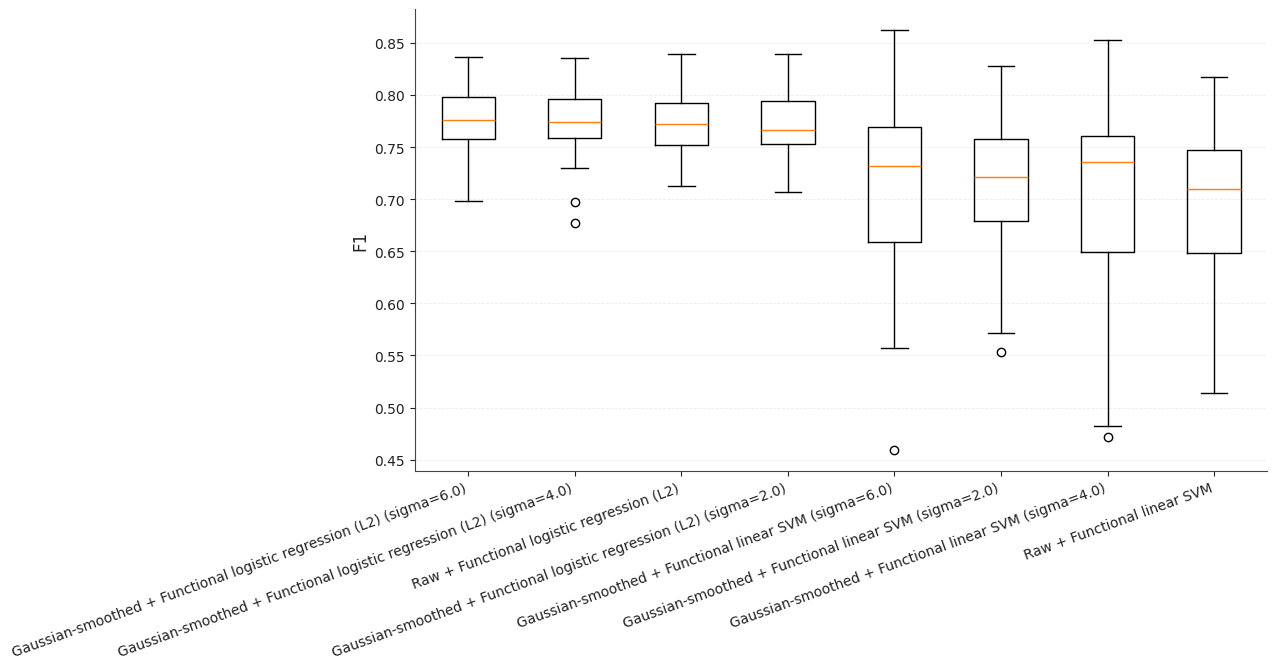

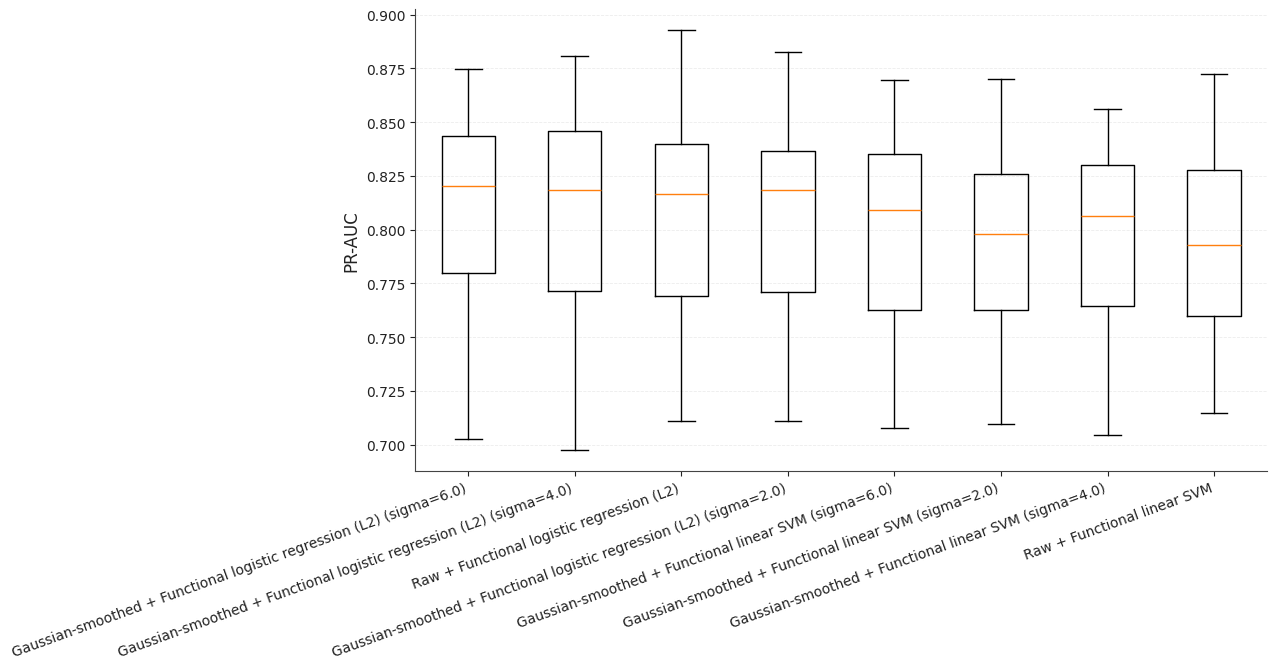

In [15]:
plot_order = summary_df["model"].tolist()

plot_metric_boxplot(
    fold_metrics_df=fold_metrics_df,
    plot_order=plot_order,
    metric="f1",
    ylabel="F1",
    show=True,
)

plot_metric_boxplot(
    fold_metrics_df=fold_metrics_df,
    plot_order=plot_order,
    metric="pr_auc",
    ylabel="PR-AUC",
    show=True,
)



 ## 15. Weight-function comparisons

In [ ]:
raw_svm_model = "Raw + Functional linear SVM"
raw_logreg_model = "Raw + Functional logistic regression (L2)"

smooth_svm_model = (
    raw_svm_model
    if best_sigma_svm == 0.0
    else f"Gaussian-smoothed + Functional linear SVM (sigma={best_sigma_svm})"
)

smooth_logreg_model = (
    raw_logreg_model
    if best_sigma_logreg == 0.0
    else f"Gaussian-smoothed + Functional logistic regression (L2) (sigma={best_sigma_logreg})"
)



plot_raw_vs_smoothed_weights(
    weight_summary_df=weight_summary_df,
    raw_model=raw_svm_model,
    smooth_model=smooth_svm_model,
    out_path=OUT_DIR / "fig_weights_svm_raw_vs_best_sigma.svg",
)

plot_raw_vs_smoothed_weights(
    weight_summary_df=weight_summary_df,
    raw_model=raw_logreg_model,
    smooth_model=smooth_logreg_model,
    out_path=OUT_DIR / "fig_weights_logreg_raw_vs_best_sigma.svg",
)

print("Saved weight-function figures.")



Saved weight-function figures.


 ## 16. Build payload for interpretability notebook

In [17]:
class_mean_curves = {
    "raw_mean_0": X_raw[y == 0].mean(axis=0),
    "raw_mean_1": X_raw[y == 1].mean(axis=0),
    "raw_diff_10": X_raw[y == 1].mean(axis=0) - X_raw[y == 0].mean(axis=0),
}

for sigma in SIGMAS:
    class_mean_curves[f"smooth_mean_0_sigma_{sigma}"] = X_smooth_dict[sigma][y == 0].mean(axis=0)
    class_mean_curves[f"smooth_mean_1_sigma_{sigma}"] = X_smooth_dict[sigma][y == 1].mean(axis=0)
    class_mean_curves[f"smooth_diff_10_sigma_{sigma}"] = (
        X_smooth_dict[sigma][y == 1].mean(axis=0)
        - X_smooth_dict[sigma][y == 0].mean(axis=0)
    )

weight_payload = {}

for model_name in weight_summary_df["model"].unique():
    sub = weight_summary_df[
        weight_summary_df["model"] == model_name
    ].sort_values("wavelength")

    safe_name = (
        model_name.lower()
        .replace(" + ", "_")
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("=", "_")
        .replace(".", "_")
        .replace("-", "_")
    )

    weight_payload[f"weights_{safe_name}"] = sub["weight_mean"].to_numpy()

payload_path = OUT_DIR / "smoothing_payload.npz"

np.savez(
    payload_path,
    wavelengths=wavelengths,
    y=y,
    source_ids=source_ids.astype(str),
    sigmas=np.array(SIGMAS, dtype=float),
    best_sigma_svm=np.array([best_sigma_svm], dtype=float),
    best_sigma_logreg=np.array([best_sigma_logreg], dtype=float),
    X_raw=X_raw,
    **{f"X_smooth_sigma_{sigma}": X_smooth_dict[sigma] for sigma in SIGMAS},
    **class_mean_curves,
    **weight_payload,
)

print("Saved interpretability payload:", payload_path)



Saved interpretability payload: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\06_smoothing\smoothing_payload.npz


 ## 17. Save main outputs

In [18]:
fold_metrics_path = OUT_DIR / "smoothing_fold_metrics.csv"
summary_path = OUT_DIR / "smoothing_summary.csv"
pretty_summary_path = OUT_DIR / "smoothing_pretty_summary.csv"
wilcoxon_path = OUT_DIR / "smoothing_wilcoxon.csv"
weight_functions_path = OUT_DIR / "smoothing_weight_functions.csv"
weight_summary_path = OUT_DIR / "smoothing_weight_summary.csv"
ranking_path = OUT_DIR / "smoothing_ranking.csv"

fold_metrics_df.to_csv(fold_metrics_path, index=False)
summary_df.to_csv(summary_path, index=False)
pretty_summary.to_csv(pretty_summary_path, index=False)
wilcoxon_df.to_csv(wilcoxon_path, index=False)
weight_functions_df.to_csv(weight_functions_path, index=False)
weight_summary_df.to_csv(weight_summary_path, index=False)
ranking.to_csv(ranking_path, index=False)

print("Saved CSV outputs to:", OUT_DIR)



Saved CSV outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\06_smoothing


 ## 18. Save figure outputs

In [19]:
plot_metric_boxplot(
    fold_metrics_df=fold_metrics_df,
    plot_order=plot_order,
    metric="f1",
    ylabel="F1",
    out_path=OUT_DIR / "fig_smoothing_boxplot_f1.svg",
    show=False,
)

plot_metric_boxplot(
    fold_metrics_df=fold_metrics_df,
    plot_order=plot_order,
    metric="pr_auc",
    ylabel="PR-AUC",
    out_path=OUT_DIR / "fig_smoothing_boxplot_pr_auc.svg",
    show=False,
)

print("Saved figure outputs to:", OUT_DIR)



Saved figure outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\06_smoothing


 ## 19. Final quick view

In [20]:
display(pretty_summary)
display(wilcoxon_df)

print("Best SVM model:", best_svm_model)
print("Best logistic regression model:", best_logreg_model)

,Model,F1,PR-AUC,ROC-AUC,Sensitivity,Precision,Best C
0,Gaussian-smoothed + Functional logistic regres...,0.7757 ± 0.0286,0.8090 ± 0.0453,0.9225 ± 0.0150,0.8212 ± 0.0327,0.7367 ± 0.0423,41.9771 ± 40.3308
1,Gaussian-smoothed + Functional logistic regres...,0.7739 ± 0.0303,0.8080 ± 0.0451,0.9219 ± 0.0144,0.8204 ± 0.0338,0.7343 ± 0.0459,46.7594 ± 42.2542
2,Raw + Functional logistic regression (L2),0.7727 ± 0.0264,0.8061 ± 0.0439,0.9223 ± 0.0137,0.8183 ± 0.0322,0.7342 ± 0.0469,50.1254 ± 43.0181
3,Gaussian-smoothed + Functional logistic regres...,0.7717 ± 0.0287,0.8076 ± 0.0429,0.9219 ± 0.0137,0.8185 ± 0.0325,0.7319 ± 0.0454,45.0764 ± 41.7633
4,Gaussian-smoothed + Functional linear SVM (sig...,0.7119 ± 0.0743,0.7996 ± 0.0430,0.9158 ± 0.0143,0.7801 ± 0.1019,0.6912 ± 0.1530,34.7431 ± 41.5287
5,Gaussian-smoothed + Functional linear SVM (sig...,0.7055 ± 0.0689,0.7947 ± 0.0405,0.9155 ± 0.0134,0.7596 ± 0.1111,0.7024 ± 0.1608,30.5029 ± 35.4450
6,Gaussian-smoothed + Functional linear SVM (sig...,0.7052 ± 0.0825,0.7980 ± 0.0403,0.9154 ± 0.0138,0.7967 ± 0.0875,0.6675 ± 0.1627,33.3355 ± 38.2066
7,Raw + Functional linear SVM,0.6934 ± 0.0744,0.7930 ± 0.0412,0.9157 ± 0.0132,0.7790 ± 0.1170,0.6674 ± 0.1579,31.9192 ± 36.8794


,model_a,model_b,metric,n_folds,mean_a,mean_b,mean_diff_a_minus_b,wilcoxon_stat,p_value,significant_0_05
0,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,f1,50,0.693444,0.705542,-0.012098,565.0,4.903262e-01,False
1,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,pr_auc,50,0.792991,0.794722,-0.001731,578.0,5.720861e-01,False
2,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,f1,50,0.693444,0.705158,-0.011714,558.0,4.490068e-01,False
3,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,pr_auc,50,0.792991,0.797964,-0.004972,489.0,1.543025e-01,False
4,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,f1,50,0.693444,0.711891,-0.018447,521.0,2.653377e-01,False
5,Raw + Functional linear SVM,Gaussian-smoothed + Functional linear SVM (sig...,pr_auc,50,0.792991,0.799576,-0.006584,443.0,6.070140e-02,False
6,Raw + Functional logistic regression (L2),Gaussian-smoothed + Functional logistic regres...,f1,50,0.772698,0.771674,0.001024,569.0,8.454913e-01,False
7,Raw + Functional logistic regression (L2),Gaussian-smoothed + Functional logistic regres...,pr_auc,50,0.806062,0.807620,-0.001558,512.0,2.297480e-01,False
8,Raw + Functional logistic regression (L2),Gaussian-smoothed + Functional logistic regres...,f1,50,0.772698,0.773893,-0.001195,632.0,9.618479e-01,False
9,Raw + Functional logistic regression (L2),Gaussian-smoothed + Functional logistic regres...,pr_auc,50,0.806062,0.807988,-0.001925,490.0,1.571404e-01,False


Best SVM model: Gaussian-smoothed + Functional linear SVM (sigma=6.0)
Best logistic regression model: Gaussian-smoothed + Functional logistic regression (L2) (sigma=6.0)
